In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [38]:
medical_df = pd.read_csv('../data/insurance.csv') 

In [39]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
medical_df.shape

(1338, 7)

In [5]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<Figure size 300x300 with 0 Axes>

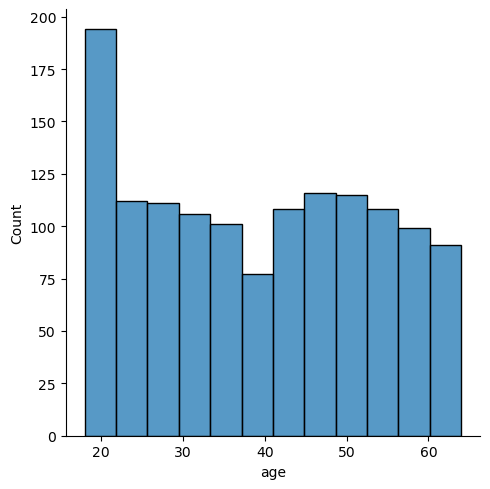

In [7]:
#Data Visualization
plt.figure(figsize=(3,3))
sns.displot(data=medical_df,x='age')

<Figure size 300x300 with 0 Axes>

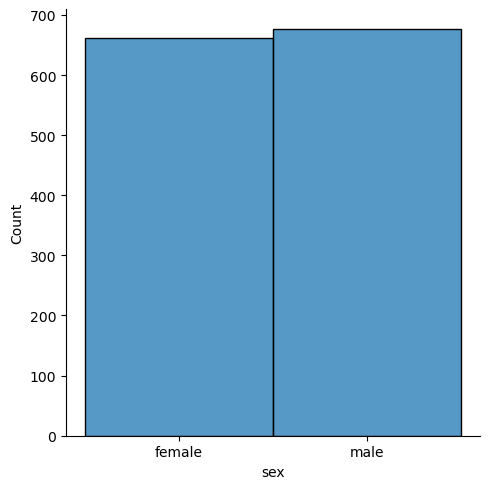

In [8]:
plt.figure(figsize=(3,3))
sns.displot(data=medical_df,x='sex',kind='hist')

In [9]:
medical_df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

<Figure size 400x400 with 0 Axes>

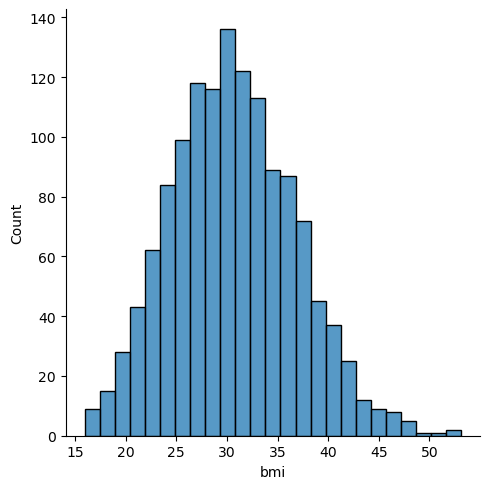

In [10]:
plt.figure(figsize=(4,4))
sns.displot(data=medical_df,x='bmi')
plt.show()

In [11]:
medical_df['bmi'].value_counts()

bmi
32.300    13
28.310     9
30.495     8
30.875     8
31.350     8
          ..
46.200     1
23.800     1
44.770     1
32.120     1
30.970     1
Name: count, Length: 548, dtype: int64

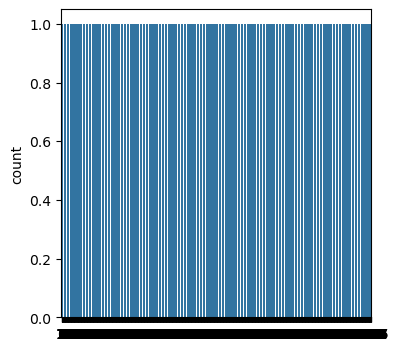

In [12]:
plt.figure(figsize=(4,4))
sns.countplot(medical_df['children'])
plt.show()

In [13]:
medical_df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

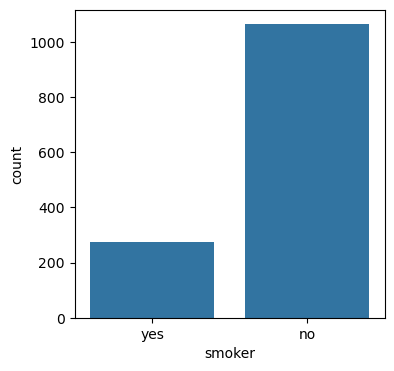

In [14]:
plt.figure(figsize=(4,4))
sns.countplot(data=medical_df,x='smoker')
plt.show()

In [ ]:
#Data PreProcessing

In [15]:
medical_df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [16]:
medical_df['sex'] = medical_df['sex'].map({'male': 1, 'female': 0})
medical_df['smoker'] = medical_df['smoker'].map({'yes': 1, 'no': 0})
medical_df['region'] = medical_df['region'].map({
    'southeast': 0,
    'southwest': 1,
    'northwest': 2,
    'northeast': 3
})

In [17]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,1,16884.92400
1,18,1,33.770,1,0,0,1725.55230
2,28,1,33.000,3,0,0,4449.46200
3,33,1,22.705,0,0,2,21984.47061
4,32,1,28.880,0,0,2,3866.85520


In [18]:
X = medical_df.drop('charges',axis=1)
y = medical_df['charges']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=2)

In [20]:
X_train.shape

(1204, 6)

In [21]:
X_test.shape

(134, 6)

In [22]:
medical_df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [23]:
#Linear Regression
lg = LinearRegression()
lg.fit(X_train,y_train) # 80 model will be train
y_pred = lg.predict(X_test) # 10 model will be predicted

In [24]:
r2_score(y_test,y_pred)

0.7058997983752826

In [25]:
#Random forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Train the model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf.predict(X_test)

# Calculate R2 score
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest R2 score:", r2_rf)


Random Forest R2 score: 0.7453920118542476


In [40]:
import pickle

pickle.dump(rf, open("../model/insurance_model.pkl", "wb"))
print("Model saved successfully!")

Model saved successfully!


In [26]:
#Gradient Boosting Regression:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Train the model
gbm = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbm.fit(X_train, y_train)

# Predict on the test set
y_pred_gbm = gbm.predict(X_test)

# Calculate R2 score
r2_gbm = r2_score(y_test, y_pred_gbm)
print("Gradient Boosting R2 score:", r2_gbm)


Gradient Boosting R2 score: 0.801191567504624


In [27]:
#Support Vector Machine (SVM) Regression:
from sklearn.svm import SVR
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
svm = SVR(kernel='rbf')
svm.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_svm = svm.predict(X_test_scaled)

# Calculate R2 score
r2_svm = r2_score(y_test, y_pred_svm)
print("SVM R2 score:", r2_svm)


SVM R2 score: -0.04014657627096763


In [28]:
#K-Nearest Neighbors (KNN) Regression:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_knn = knn.predict(X_test_scaled)

# Calculate R2 score
r2_knn = r2_score(y_test, y_pred_knn)
print("KNN R2 score:", r2_knn)


KNN R2 score: 0.7390091493281228


In [29]:
results = {
    "Linear Regression": r2_score(y_test, y_pred),
    "Random Forest": r2_rf,
    "Gradient Boosting": r2_gbm,
    "SVM": r2_svm,
    "KNN": r2_knn
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "R2 Score"])
results_df.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score
2,Gradient Boosting,0.801192
1,Random Forest,0.745392
4,KNN,0.739009
0,Linear Regression,0.705900
3,SVM,-0.040147


In [30]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred_gbm)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbm))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2515.8197223338802
RMSE: 4774.137354187024


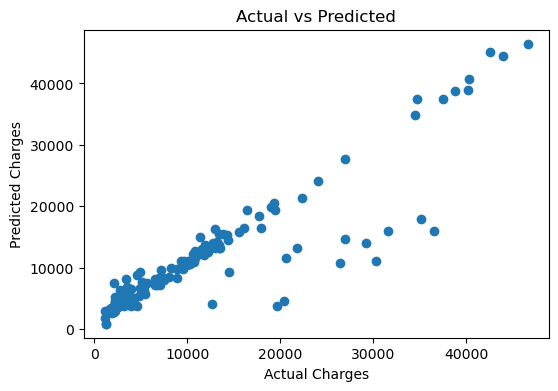

In [32]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_gbm)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()

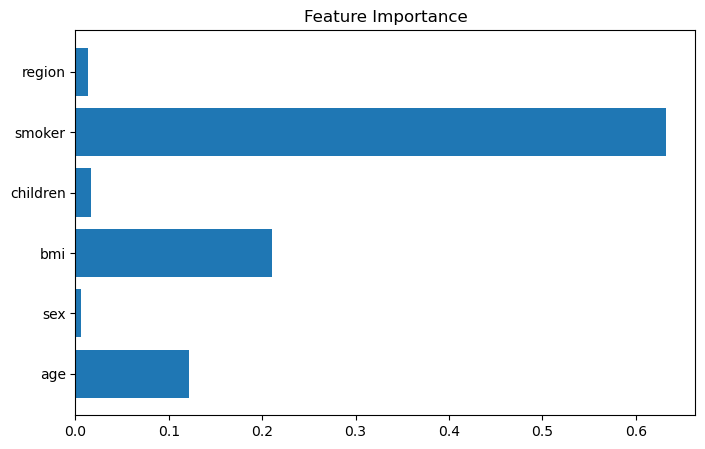

In [33]:
importance = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [34]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5)
print("Cross Validation Score:", cv_scores.mean())

Cross Validation Score: 0.8358290460540445


In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestRegressor(), params, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 5, 'n_estimators': 100}


In [36]:
import pickle

pickle.dump(gbm, open("../model/insurance_model.pkl", "wb"))
print("Model saved successfully!")

Model saved successfully!
